#  Análisis del Mercado Financiero mediante Aprendizaje No Supervisado

### PCA • Gaussian Mixture Models • Detección de Anomalías

---

##  Integrantes

- Juliana Moreno Parra  
- Dylan Sneyder Wilches Gil

---

##  Introducción

El análisis de mercados financieros implica trabajar con grandes volúmenes de datos caracterizados por alta dimensionalidad, ruido y comportamientos complejos. En este proyecto se aplican técnicas de aprendizaje no supervisado para identificar patrones ocultos, reducir dimensionalidad y detectar comportamientos anómalos dentro de datos financieros.

---

##  Objetivo del Proyecto

Aplicar técnicas de aprendizaje no supervisado para analizar el comportamiento del mercado financiero, identificar estructuras latentes en los datos y detectar anomalías relevantes mediante modelos probabilísticos y reducción de dimensionalidad.

---

##  Técnicas Implementadas

| Técnica | Aplicación |
|---|---|
| PCA | Reducción de dimensionalidad |
| GMM | Modelado probabilístico del mercado |
| Detección de anomalías | Identificación de comportamientos atípicos |



 ## **Introducción**

El análisis de mercados financieros constituye un problema complejo caracterizado por alta dimensionalidad, dependencia temporal, correlaciones entre activos y presencia de ruido. En este contexto, los enfoques tradicionales basados en modelos supervisados presentan limitaciones, ya que requieren etiquetas explícitas y suelen enfocarse en tareas de predicción, dejando de lado el entendimiento estructural del sistema.

Este trabajo aborda el estudio del mercado financiero desde una perspectiva de aprendizaje no supervisado, con el objetivo de identificar patrones latentes, reducir la dimensionalidad de los datos y modelar la dinámica del mercado sin recurrir a información etiquetada. Para ello, se emplean técnicas como el Análisis de Componentes Principales (PCA), que permite representar los datos en un subespacio de menor dimensión maximizando la varianza explicada; algoritmos de clustering, que facilitan la segmentación de activos en función de su comportamiento estadístico; y Modelos de Mezclas Gaussianas (GMM), que permiten modelar la distribución de los datos y capturar distintos regímenes del mercado desde un enfoque probabilístico.

Adicionalmente, se implementa un esquema de detección de anomalías basado en log-verosimilitud, donde observaciones con baja probabilidad bajo el modelo son interpretadas como eventos atípicos o extremos. Este enfoque resulta particularmente relevante en el análisis financiero, donde la identificación de episodios de alta volatilidad o crisis es fundamental.

Finalmente, se desarrolla un sistema de recomendación basado en medidas de similitud (cosine similarity) sobre la matriz de retornos, complementado con un enfoque híbrido que integra información estructural derivada del clustering. Este sistema permite sugerir activos con comportamientos similares, contribuyendo potencialmente a la construcción de portafolios y estrategias de diversificación.

El análisis se realiza sobre datos históricos de acciones obtenidos desde Yahoo Finance, considerando activos representativos de distintos sectores económicos. En conjunto, este enfoque permite no solo caracterizar la estructura interna del mercado, sino también evidenciar la capacidad de los métodos no supervisados para extraer información relevante en contextos donde las etiquetas son inexistentes o limitadas.

In [ ]:
#!pip install scikit-learn-extra==0.3.0
#!pip install numpy==1.26.4
#!pip install pandas==2.2.2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\dysne\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\dysne\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\dysne\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA, NMF
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.covariance import EmpiricalCovariance, LedoitWolf, GraphicalLasso

from sklearn_extra.cluster import KMedoids

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## **Datos**

Se descargaron datos históricos de precios ajustados desde Yahoo Finance para 9 acciones representativas de tres sectores: tecnología, finanzas y consumo.

Se seleccionó un subconjunto representativo de nueve activos con el objetivo de facilitar la interpretabilidad visual y pedagógica de las técnicas de aprendizaje no supervisado durante la presentación.

In [3]:
tickers = [
    # Tecnología
    "AAPL", "MSFT", "NVDA", # Apple, Microsoft, NVIDIA

    # Finanzas
    "JPM", "BAC", "V", # JPMorgan Chase, Bank of America, Visa

    # Consumo
    "AMZN", "WMT", "KO" # Amazon, Walmart, Coca-Cola
]

In [4]:

start_date = "2020-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"]
prices.head()

Ticker,AAPL,AMZN,BAC,JPM,KO,MSFT,NVDA,V,WMT
Date,,,,,,,,,
2020-01-02,72.400536,94.900497,30.587563,118.430321,45.432705,152.158356,5.970755,182.809296,36.359211
2020-01-03,71.696648,93.748497,29.952463,116.867485,45.184849,150.263733,5.875187,181.355362,36.038235
2020-01-06,72.267937,95.143997,29.909554,116.774529,45.168327,150.652176,5.899826,180.963226,35.964859
2020-01-07,71.928047,95.343002,29.712158,114.789291,44.821320,149.278549,5.971253,180.484955,35.631657
2020-01-08,73.085121,94.598503,30.012533,115.684784,44.903942,151.656342,5.982452,183.574448,35.509388


In [5]:
# Verificar dimensiones
print(prices.shape)

(1508, 9)


In [6]:
print("Valores faltantes:", prices.isnull().sum().sum())

Valores faltantes: 0


Cada columna representa una acción y cada fila una fecha. Los valores corresponden a precios de cierre ajustados, lo que permite trabajar con datos consistentes frente a splits y dividendos.

Es importante notar que los precios no son directamente comparables entre activos debido a sus diferentes escalas, por lo que posteriormente se transformarán en retornos.

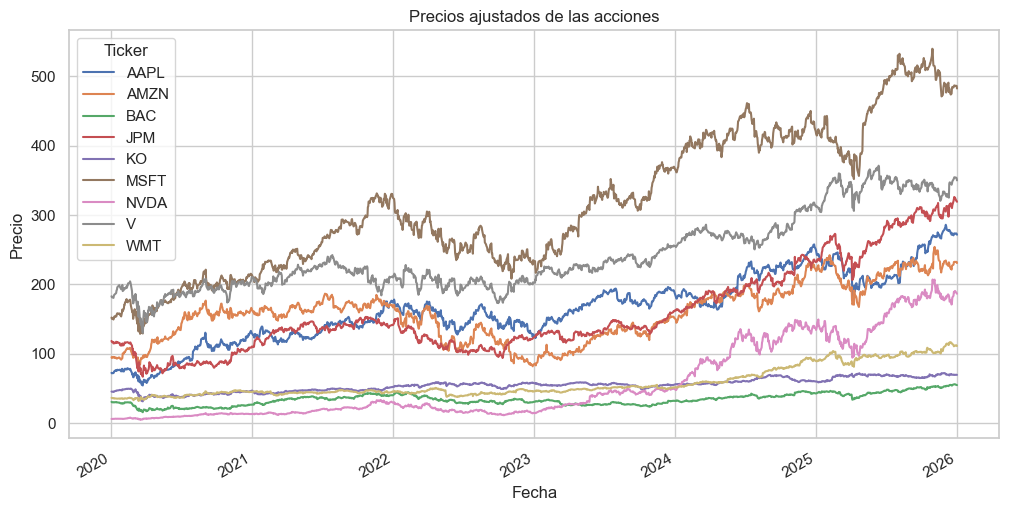

In [7]:
prices.plot(figsize=(12,6))
plt.title("Precios ajustados de las acciones")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

In [8]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,BAC,JPM,KO,MSFT,NVDA,V,WMT
Date,,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.020763,-0.013196,-0.005455,-0.012452,-0.016006,-0.007953,-0.008828
2020-01-06,0.007968,0.014886,-0.001433,-0.000795,-0.000366,0.002585,0.004194,-0.002162,-0.002036
2020-01-07,-0.004703,0.002092,-0.006600,-0.017001,-0.007683,-0.009118,0.012107,-0.002643,-0.009265
2020-01-08,0.016087,-0.007809,0.010109,0.007801,0.001843,0.015929,0.001875,0.017118,-0.003431
2020-01-09,0.021241,0.004799,0.001716,0.003651,0.018215,0.012493,0.010982,0.006930,0.010330


Debido a que los precios de las acciones se encuentran en diferentes escalas, se calcularon los retornos diarios porcentuales. Esto permite comparar el comportamiento relativo entre activos de forma consistente.

Los retornos representan el cambio porcentual diario en el precio de cada acción, lo que facilita el análisis estadístico y la aplicación de modelos de aprendizaje no supervisado.

Esta transformación es fundamental, ya que elimina problemas de escala y permite capturar la dinámica real del mercado.

##  **Análisis exploratorio**

###  **Visualización de retornos**

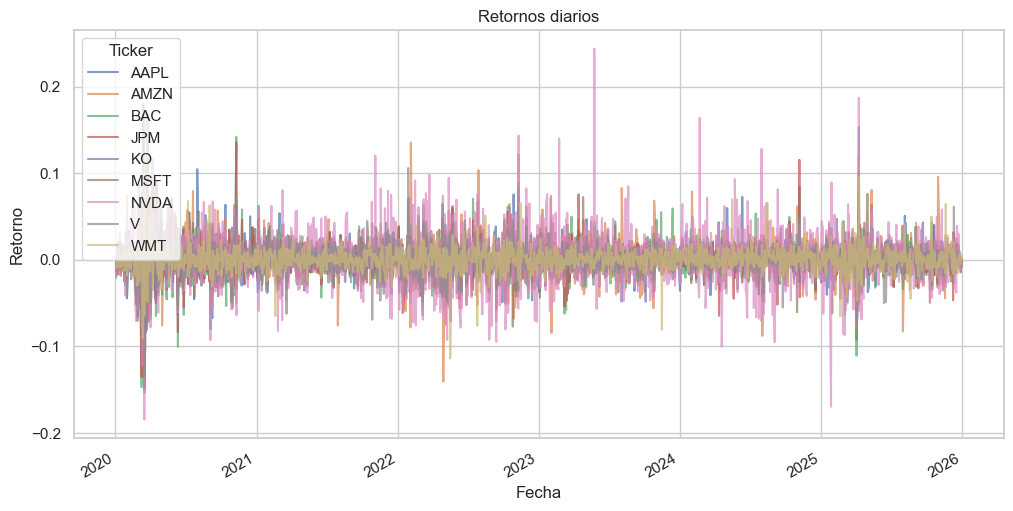

In [9]:
returns.plot(figsize=(12,6), alpha=0.7)
plt.title("Retornos diarios")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.show()

- NVDA destaca con picos más altos, es decir, que presenta una mayor volatilidad

- KO y WMT se ven mucho más estables, presentan una menor variación

### **Volatilidad (riesgo)**

In [10]:
volatility = returns.std() * np.sqrt(252)
volatility = volatility.sort_values(ascending=False)

print(volatility)

Ticker
NVDA    0.531849
AMZN    0.357027
BAC     0.344031
AAPL    0.318095
JPM     0.313783
MSFT    0.295473
V       0.270640
WMT     0.230032
KO      0.202876
dtype: float64


- NVDA es el activo más riesgoso

- KO es el activo más defensivo

- El sector de finanzas (BAC, JPM) presenta una volatilidad media-alta

- El sector tecnológico  generalmente es el más volátil

La volatilidad confirma diferencias de riesgo entre sectores, donde tecnología es más agresiva y consumo más defensivo.

### **Matriz de correlación**

In [11]:
corr_matrix = returns.corr()

corr_matrix 

Ticker,AAPL,AMZN,BAC,JPM,KO,MSFT,NVDA,V,WMT
Ticker,,,,,,,,,
AAPL,1.000000,0.588252,0.428886,0.421788,0.390632,0.709150,0.578635,0.571845,0.371073
AMZN,0.588252,1.000000,0.310742,0.298721,0.167241,0.664952,0.578444,0.402675,0.290521
BAC,0.428886,0.310742,1.000000,0.883139,0.462925,0.417967,0.324072,0.593650,0.272096
JPM,0.421788,0.298721,0.883139,1.000000,0.479390,0.426838,0.341674,0.612352,0.261975
KO,0.390632,0.167241,0.462925,0.479390,1.000000,0.367541,0.155286,0.534031,0.371202
MSFT,0.709150,0.664952,0.417967,0.426838,0.367541,1.000000,0.675692,0.579676,0.364448
NVDA,0.578635,0.578444,0.324072,0.341674,0.155286,0.675692,1.000000,0.448124,0.223726
V,0.571845,0.402675,0.593650,0.612352,0.534031,0.579676,0.448124,1.000000,0.314034
WMT,0.371073,0.290521,0.272096,0.261975,0.371202,0.364448,0.223726,0.314034,1.000000


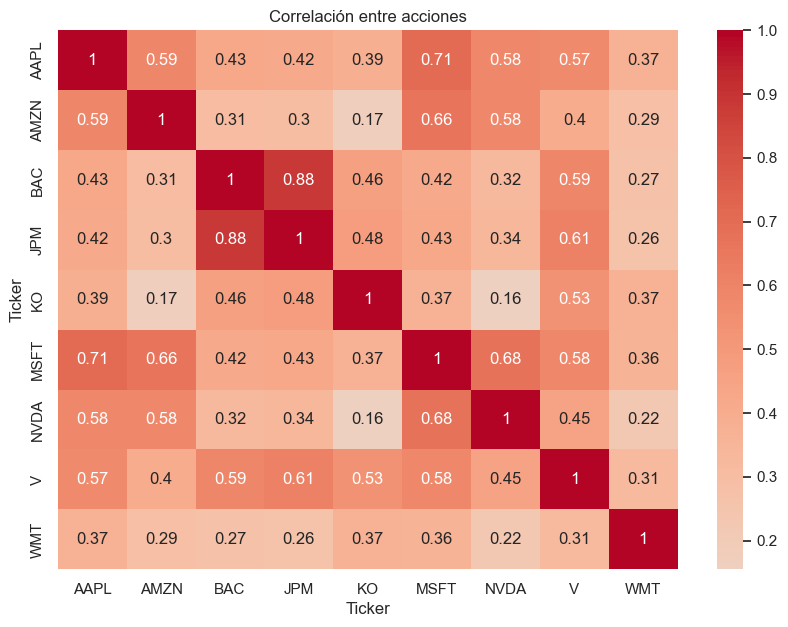

In [12]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Correlación entre acciones")
plt.show()

El análisis de correlación revela que las acciones no se comportan de forma independiente, sino que presentan relaciones claras entre sí.

Se observa que las acciones del mismo sector, como los bancos (BAC y JPM), tienen correlaciones muy altas, mientras que las tecnológicas también muestran una fuerte relación entre ellas.

Por otro lado, las acciones de consumo presentan correlaciones más bajas, lo que sugiere un comportamiento más independiente.

Estos resultados confirman que el mercado financiero tiene una estructura interna, lo cual justifica el uso de técnicas como PCA y clustering para su análisis.

## **PCA (Factores del mercado)**

### **Estandarización**

In [14]:
scaler = StandardScaler()

returns_scaled = scaler.fit_transform(returns)

### **Varianza explicada**

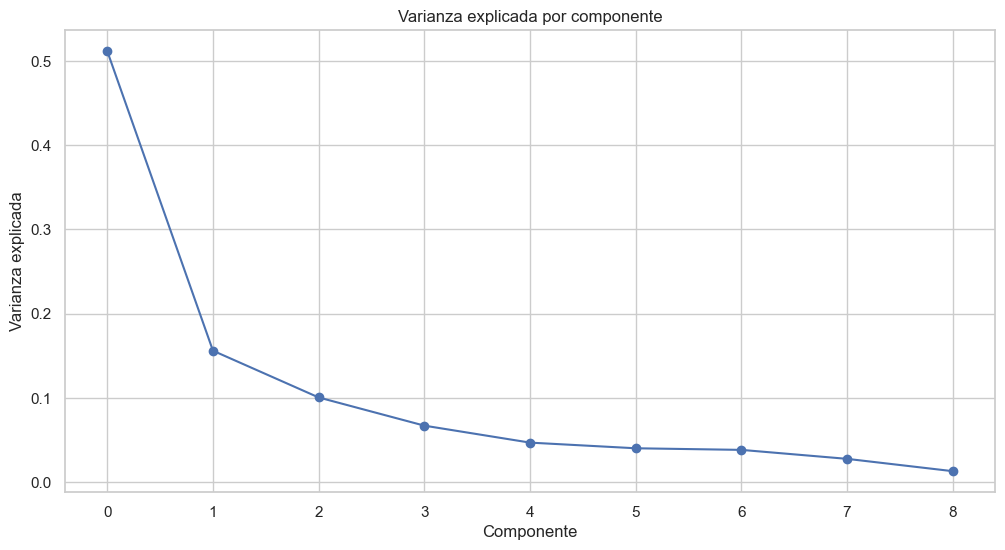

In [15]:
# Aplicar PCA
pca = PCA()
pca.fit(returns_scaled)
explained_variance = pca.explained_variance_ratio_

plt.plot(explained_variance, marker='o')
plt.title("Varianza explicada por componente")
plt.xlabel("Componente")
plt.ylabel("Varianza explicada")
plt.show()

### **Varianza acumulada**

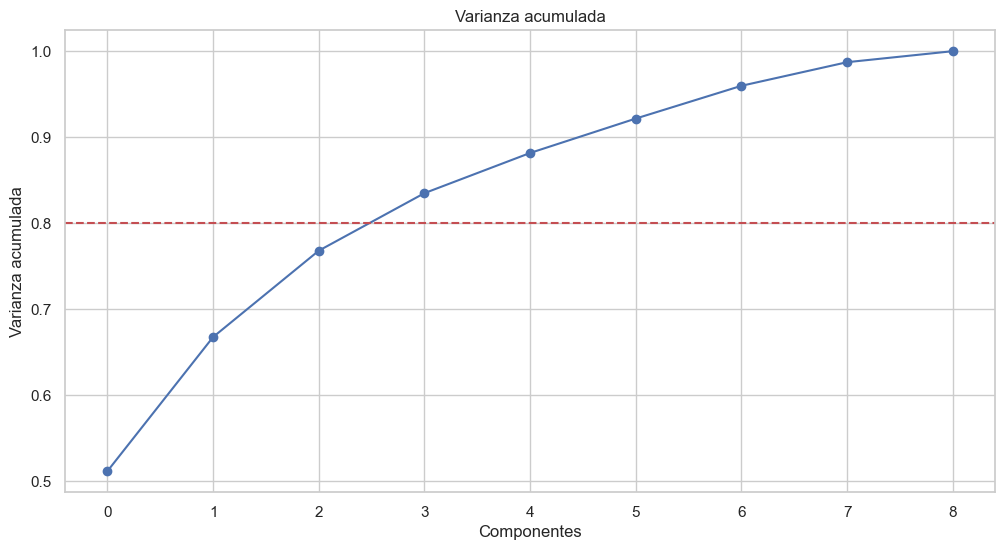

In [16]:
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title("Varianza acumulada")
plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.show()


El análisis de PCA muestra que el primer componente principal explica aproximadamente el **$51\%$** de la varianza total, lo que indica la existencia de un factor global dominante en el mercado.

Adicionalmente, al analizar la varianza acumulada, se observa que con aproximadamente cuatro componentes principales se logra capturar más del $80\%$ de la información total. Esto demuestra que el comportamiento del mercado puede representarse de manera eficiente mediante un número reducido de factores.

Aunque aproximadamente cuatro componentes principales capturan más del **$80\%$** de la varianza, para las etapas posteriores se utilizaron únicamente las dos primeras componentes principales con fines de visualización e interpretabilidad.

### **Reducción de dimensiones**

Aunque el análisis de varianza acumulada indica que aproximadamente cuatro componentes principales capturan más del **$80\%$** de la información, para fines de visualización e interpretabilidad se trabajó con las dos primeras componentes principales.


In [17]:
pca = PCA(n_components=2)

returns_pca = pca.fit_transform(returns_scaled)

### **Visualización en 2D**

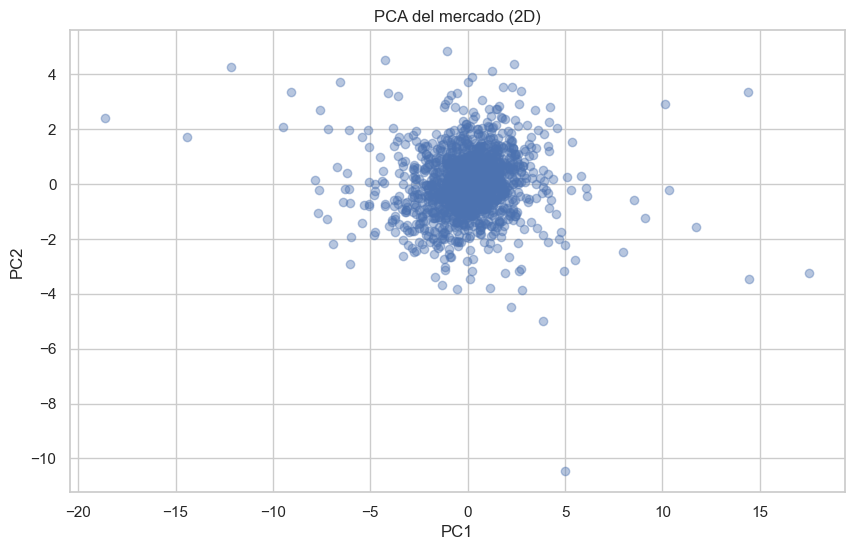

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    returns_pca[:,0],
    returns_pca[:,1],
    alpha=0.4
)

plt.title("PCA del mercado (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

La proyección de los datos en los dos primeros componentes principales muestra una alta concentración de observaciones alrededor del origen, lo que indica que la mayoría de los días presentan un comportamiento normal del mercado.

Sin embargo, también se observan puntos alejados de la región central, los cuales pueden interpretarse como eventos atípicos o anomalías. Esto sugiere que, aunque el mercado tiene un comportamiento general estable, existen episodios extremos que pueden ser detectados mediante técnicas de reducción de dimensionalidad.

## **Clustering**

Se utilizó K-Means como método base de agrupamiento por su simplicidad e interpretabilidad. Posteriormente, se aplicó Gaussian Mixture Models (GMM) para incorporar un enfoque probabilístico más flexible y adecuado para modelar posibles regímenes del mercado financiero.

### **Aplicar K-means**

Para el análisis de clustering, se transpone la matriz de retornos con el fin de que cada observación represente un activo financiero y no un instante temporal

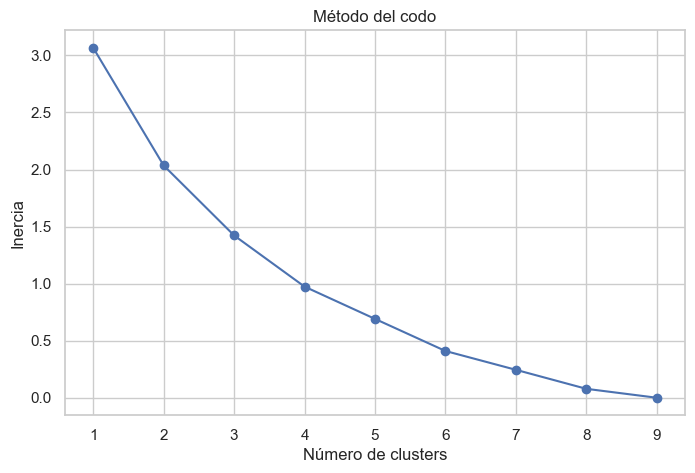

In [19]:
# Transponer datos
X_assets = returns.T

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_assets)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

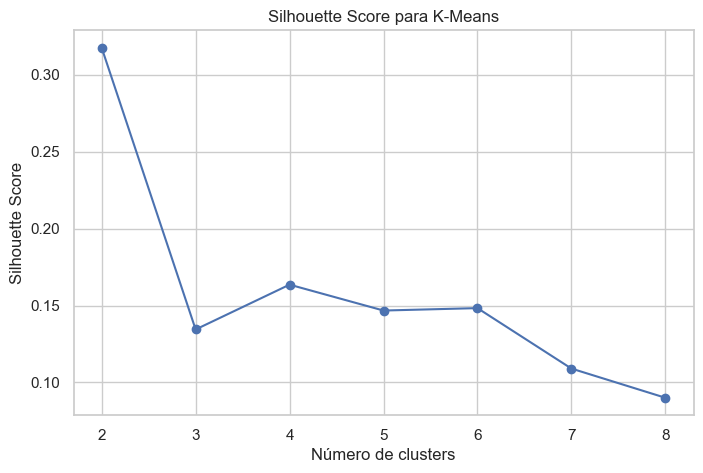

In [40]:
silhouette_scores = []

# Probar distintos valores de k
for k in range(2, 9):  # empieza en 2 porque silhouette no funciona con k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_assets)

    score = silhouette_score(X_assets, labels)
    silhouette_scores.append(score)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.title("Silhouette Score para K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_assets)

In [21]:
cluster_df = pd.DataFrame({
    "Asset": X_assets.index,
    "Cluster": clusters
})

cluster_df.sort_values("Cluster")

,Asset,Cluster
2,BAC,0
3,JPM,0
4,KO,0
7,V,0
6,NVDA,1
0,AAPL,2
1,AMZN,2
5,MSFT,2
8,WMT,2


Se utilizó el método del codo para analizar la variación de la inercia en función del número de clusters. La gráfica muestra un punto de inflexión alrededor de k=3, indicando que a partir de este valor la reducción de la inercia comienza a desacelerarse significativamente.

Complementariamente, se evaluó el silhouette score, el cual favoreció una configuración de k=2, sugiriendo una mejor separación geométrica global entre clusters. Sin embargo, se decidió trabajar con k=3 debido a que esta configuración permite una interpretación financiera más consistente con la composición sectorial del conjunto de activos, conformado por empresas de tecnología, finanzas y consumo.

En consecuencia, la elección de tres clusters responde a un equilibrio entre criterios estadísticos de agrupamiento e interpretabilidad financiera de los resultados.

### **Visualización con PCA**

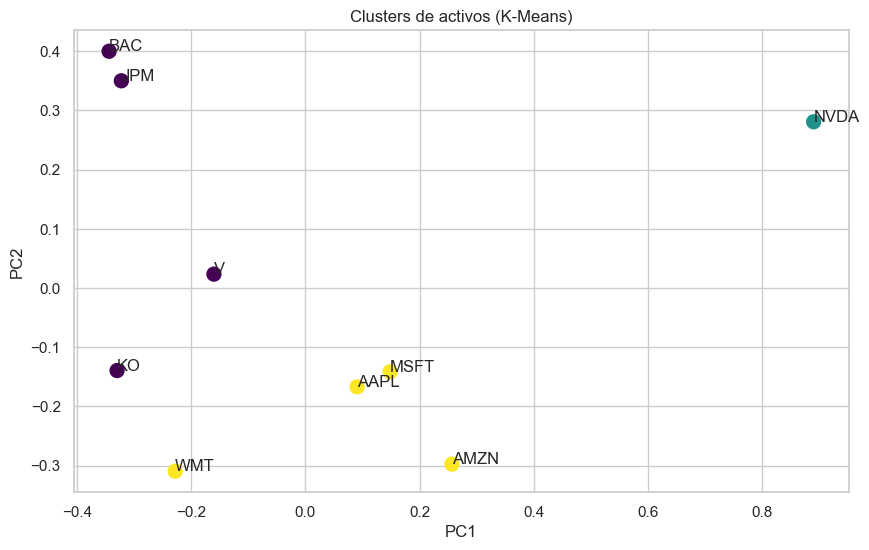

In [22]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_assets)

plt.figure(figsize=(10,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=clusters,
    cmap="viridis",
    s=100
)

# Etiquetas
for i, asset in enumerate(X_assets.index):
    plt.annotate(asset, (X_vis[i,0], X_vis[i,1]))

plt.title("Clusters de activos (K-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

El modelo K-Means permitió agrupar los activos según su comportamiento histórico.

Se observa que las acciones tienden a organizarse en grupos coherentes, donde los activos financieros se agrupan entre sí y las empresas tecnológicas forman otro grupo.

Adicionalmente, se identifica que Nvidia aparece como un cluster independiente, lo que indica un comportamiento significativamente distinto al resto de los activos, consistente con su alta volatilidad observada previamente.

Estos resultados confirman que el mercado presenta estructura interna y que los activos no se comportan de forma homogénea.

### **GMM (Regímenes del mercado)**

#### **Entrenar GMM**

Utilizamos dos componentes principales para representar los datos en 2D y facilitar la visualización. Posteriormente, aplicamos GMM con tres componentes para identificar distintos regímenes del mercado.

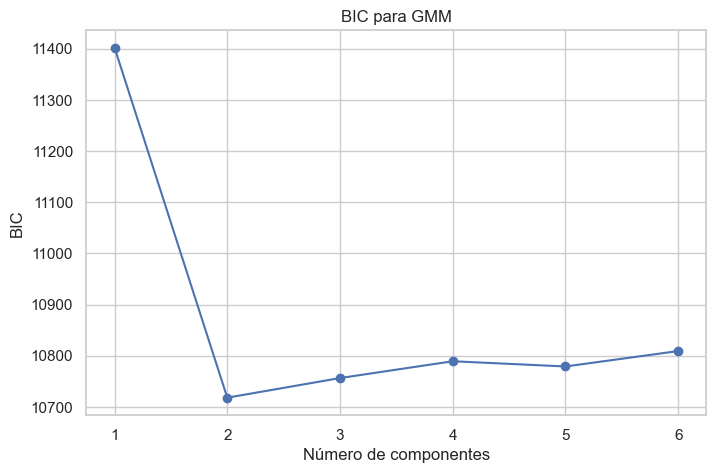

In [38]:
bic_scores = []

for k in range(1, 7):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(returns_pca)
    bic_scores.append(gmm.bic(returns_pca))

plt.figure(figsize=(8,5))
plt.plot(range(1, 7), bic_scores, marker='o')
plt.title("BIC para GMM")
plt.xlabel("Número de componentes")
plt.ylabel("BIC")
plt.show()

El criterio BIC indicó que un modelo con dos componentes gaussianos ofrecía el mejor balance entre complejidad y ajuste estadístico. No obstante, se optó por utilizar tres componentes gaussianos con el fin de mantener coherencia con la composición sectorial del conjunto de activos (tecnología, finanzas y consumo) y facilitar la interpretabilidad financiera de los clusters obtenidos. Adicionalmente, la diferencia en los valores de BIC entre los modelos de dos y tres componentes fue relativamente pequeña (aproximadamente 35 unidades), lo que sugiere que ambas configuraciones presentan desempeños comparables.

In [23]:
gmm = GaussianMixture(n_components=3, random_state=42)

gmm.fit(returns_pca)

regimes = gmm.predict(returns_pca)

#### **Resultados**

In [24]:
df_regimes = pd.DataFrame(returns_pca, columns=["PC1", "PC2"])
df_regimes["Regime"] = regimes
df_regimes.index = returns.index

df_regimes.head()

,PC1,PC2,Regime
Date,,,
2020-01-03,-1.897399,0.170608,0
2020-01-06,0.187911,0.511638,0
2020-01-07,-1.048111,0.716357,0
2020-01-08,1.057492,-0.288856,0
2020-01-09,1.495715,-0.114993,0


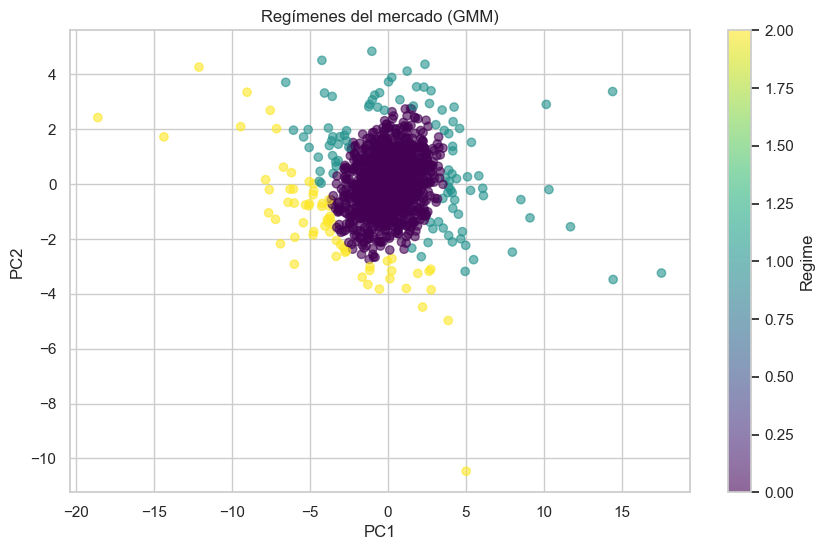

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_regimes["PC1"],
    df_regimes["PC2"],
    c=df_regimes["Regime"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Regímenes del mercado (GMM)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Regime")
plt.show()

El modelo Gaussian Mixture Model permitió identificar tres regímenes distintos en el comportamiento del mercado.

Se observa que la mayoría de las observaciones se concentran en un régimen central, el cual representa condiciones normales del mercado. Adicionalmente, se identifican otros regímenes que corresponden a periodos de mayor volatilidad y a eventos extremos o atípicos.

Estos resultados evidencian que el mercado financiero no presenta un comportamiento uniforme, sino que evoluciona entre distintos estados, lo que es fundamental para el análisis de riesgo y toma de decisiones.

#### **Evolución temporal**

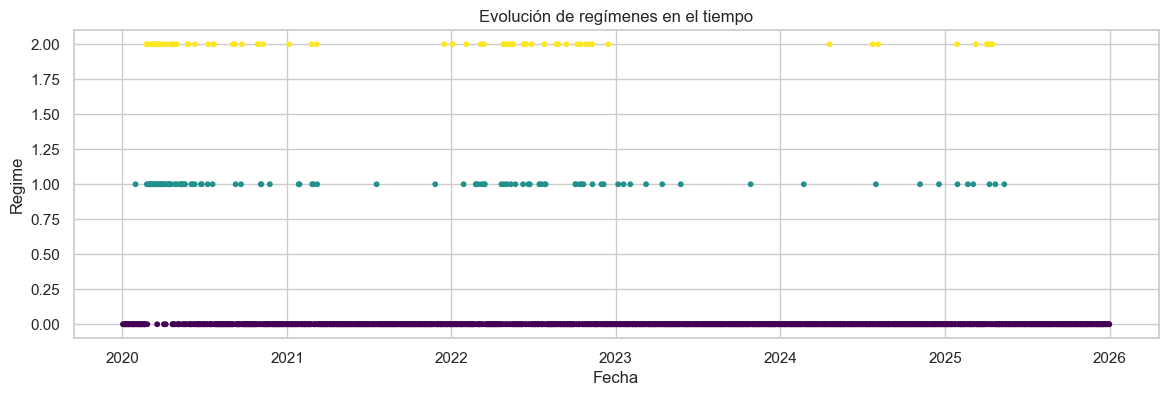

In [26]:
plt.figure(figsize=(14,4))

plt.scatter(
    df_regimes.index,
    df_regimes["Regime"],
    c=df_regimes["Regime"],
    cmap="viridis",
    s=10
)

plt.title("Evolución de regímenes en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Regime")
plt.show()

La visualización temporal de los regímenes permite observar cómo el mercado cambia de estado a lo largo del tiempo.

Se evidencia que el mercado permanece la mayor parte del tiempo en un régimen estable, mientras que los regímenes asociados a mayor volatilidad o eventos extremos aparecen en periodos específicos.

Adicionalmente, se observa que los regímenes presentan persistencia temporal, lo que indica que una vez el mercado entra en un determinado estado, tiende a mantenerse en él durante cierto periodo.

## **Anomalías (detección de días raros del mercado)**

La detección de anomalías en este proyecto se basa en la probabilidad de cada observación bajo el modelo probabilístico aprendido mediante Gaussian Mixture Models (GMM).

### **Fundamento del método**

El modelo GMM asume que los datos siguen una combinación de distribuciones gaussianas, donde cada componente representa un posible régimen del mercado. Una vez ajustado el modelo, es posible evaluar qué tan probable es cada observación dentro de esta distribución.

Para ello, se utiliza la función `score_samples()`, la cual calcula la **log-verosimilitud** de cada punto:

$$
\text{Anomaly Score} = \log P(x)
$$

donde $P(x)$ es la probabilidad de observar el dato $x$ bajo el modelo.

### **Interpretación del anomaly score**

El valor obtenido (log-likelihood) permite medir qué tan bien se ajusta una observación al comportamiento aprendido por el modelo:

- Valores **altos (menos negativos)** → observaciones más probables → comportamiento normal  
- Valores **bajos (más negativos)** → observaciones poco probables → comportamiento atípico  

Debido a que se trabaja en escala logarítmica, todos los valores son negativos, y una menor magnitud (más cercano a cero) indica mayor probabilidad.

### **Funcionamiento del algoritmo**

El proceso de detección de anomalías se realiza en los siguientes pasos:

1. Se entrena el modelo GMM sobre los datos transformados (PCA).
2. Se calcula la log-verosimilitud de cada observación utilizando `score_samples()`.
3. Se construye un índice de anomalía (Anomaly Score) para cada punto.
4. Se define un umbral basado en percentiles (por ejemplo, el 5% inferior).
5. Las observaciones con valores por debajo de este umbral se clasifican como anomalías.

### **Definición del umbral**

El uso de percentiles permite identificar anomalías sin asumir una distribución específica de los datos. En este caso, se selecciona el percentil 5, lo que implica que el 5% de las observaciones menos probables se consideran eventos atípicos.

Este umbral actúa como un hiperparámetro que controla la sensibilidad del modelo:

- Valores más bajos (1%) → detectan solo eventos extremos  
- Valores más altos (10%) → incluyen más observaciones  

### **Interpretación en contexto financiero**

En el contexto del mercado financiero, las anomalías detectadas corresponden a:

- periodos de alta volatilidad,  
- shocks del mercado,  
- eventos extremos o inusuales.  

Estas observaciones se caracterizan por desviarse significativamente del comportamiento normal aprendido por el modelo.


### **Score de anomalía**

In [27]:
# Log-probabilidad de cada punto
log_likelihood = gmm.score_samples(returns_pca)

df_regimes["Anomaly_Score"] = log_likelihood

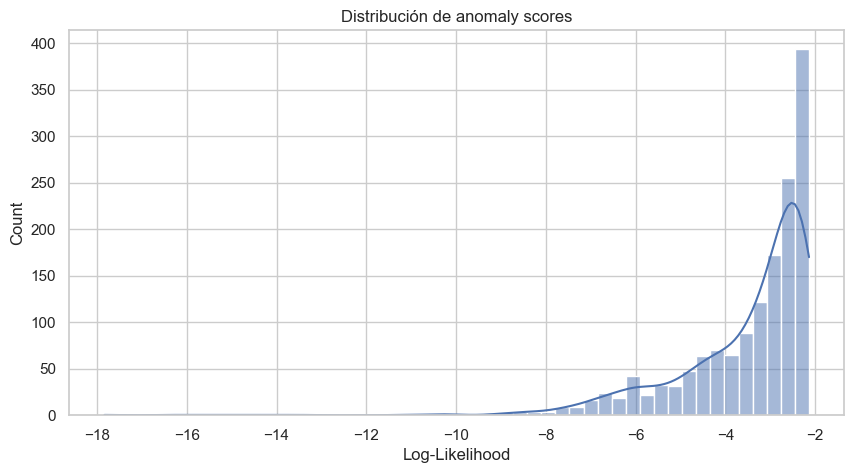

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(df_regimes["Anomaly_Score"], bins=50, kde=True)

plt.title("Distribución de anomaly scores")
plt.xlabel("Log-Likelihood")
plt.show()

La distribución del score de anomalía muestra que la mayoría de las observaciones tienen alta probabilidad bajo el modelo, lo que corresponde a comportamiento normal del mercado.

Sin embargo, se observa una cola hacia valores más bajos de log-likelihood, lo que indica la presencia de eventos poco frecuentes o anómalos. Estos valores representan días en los que el comportamiento del mercado se desvía significativamente del patrón habitual.

### **Definir anomalías**

In [29]:
# Umbral: 5% más bajo
threshold = df_regimes["Anomaly_Score"].quantile(0.05)

df_regimes["Anomaly"] = df_regimes["Anomaly_Score"] < threshold

Para identificar observaciones atípicas, se definió un umbral basado en el percentil 5 de la distribución de anomaly scores.

Este enfoque permite seleccionar las observaciones con menor probabilidad bajo el modelo, las cuales corresponden a comportamientos poco frecuentes o anómalos en el mercado.

### **Visualización en PCA**

Las anomalías se concentran en regiones alejadas del comportamiento promedio, lo que confirma que el modelo identifica correctamente eventos extremos del mercado.

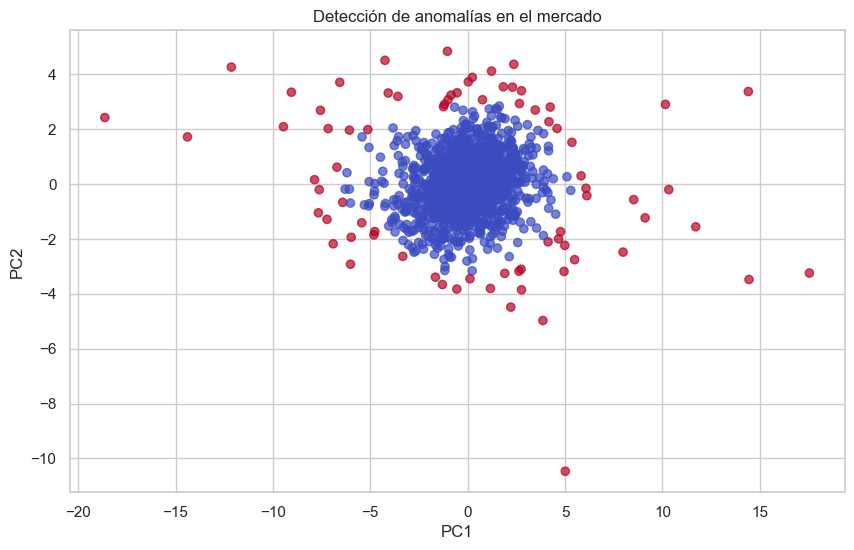

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_regimes["PC1"],
    df_regimes["PC2"],
    c=df_regimes["Anomaly"],
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Detección de anomalías en el mercado")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

La visualización de las anomalías en el espacio de los componentes principales muestra que los puntos identificados como atípicos se encuentran alejados de la región central donde se concentra el comportamiento normal del mercado.

Esto confirma que el modelo GMM, junto con el umbral definido, permite identificar correctamente observaciones con baja probabilidad, correspondientes a eventos extremos o inusuales en el mercado.

Este resultado valida la efectividad del enfoque no supervisado para la detección de anomalías en datos financieros.

### **Anomalías en el tiempo**

Las anomalías no ocurren de forma aislada, sino en periodos donde el mercado presenta caídas abruptas en probabilidad, lo que sugiere episodios de alta inestabilidad o crisis.

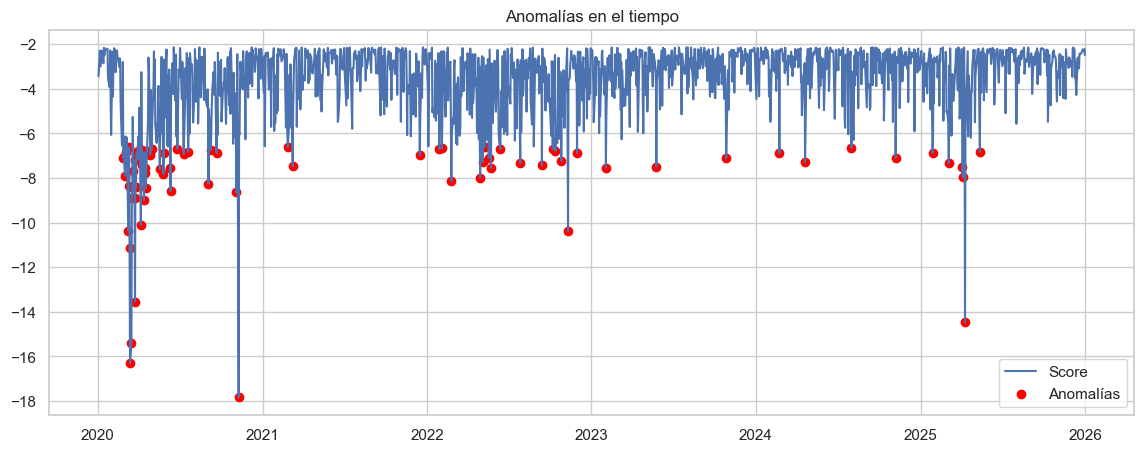

In [31]:
plt.figure(figsize=(14,5))

plt.plot(df_regimes.index, df_regimes["Anomaly_Score"], label="Score")

plt.scatter(
    df_regimes.index[df_regimes["Anomaly"]],
    df_regimes["Anomaly_Score"][df_regimes["Anomaly"]],
    color='red',
    label='Anomalías'
)

plt.title("Anomalías en el tiempo")
plt.legend()
plt.show()

La visualización de los anomaly scores en el tiempo permite identificar los momentos en los que el mercado presenta comportamientos atípicos.

Se observa que las anomalías coinciden con caídas significativas en la probabilidad del modelo, y que estas no ocurren de forma aislada, sino en periodos específicos.

Esto sugiere la presencia de eventos extremos o episodios de alta volatilidad en el mercado, los cuales pueden ser detectados automáticamente mediante el enfoque propuesto.

## **Sistema de recomendación**

El sistema de recomendación desarrollado en este proyecto tiene como objetivo identificar activos financieros con comportamientos similares, utilizando únicamente información histórica de retornos. Este enfoque se basa en aprendizaje no supervisado y no requiere etiquetas explícitas.

### **Fundamento del sistema**

El modelo parte de la hipótesis de que activos que presentan patrones similares en sus retornos tienden a reaccionar de manera comparable ante condiciones del mercado. Por lo tanto, estos activos pueden considerarse sustitutos o complementarios dentro de un portafolio.

### **Medida de similitud**

Para cuantificar la similitud entre activos, se utiliza la **cosine similarity**, definida como:

$$
\text{sim}(x, y) = \frac{x \cdot y}{\|x\| \|y\|}
$$

donde \(x\) y \(y\) son los vectores de retornos de dos activos.

Esta medida evalúa el ángulo entre los vectores, capturando la similitud en la **forma del comportamiento** más que en su magnitud. Un valor cercano a 1 indica alta similitud, mientras que valores cercanos a 0 indican baja relación.

### **Funcionamiento del algoritmo**

1. Se construye una matriz de retornos donde cada fila representa un activo y cada columna un instante temporal.
2. Se calcula la matriz de similitud entre todos los pares de activos utilizando cosine similarity.
3. Para un activo dado, se ordenan los demás activos según su nivel de similitud.
4. Se seleccionan los activos con mayor similitud (excluyendo el propio activo) como recomendaciones.



### **Similitud entre activos**

In [32]:
# Similaridad entre activos
similarity_matrix = cosine_similarity(X_assets)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=X_assets.index,
    columns=X_assets.index
)

similarity_df

Ticker,AAPL,AMZN,BAC,JPM,KO,MSFT,NVDA,V,WMT
Ticker,,,,,,,,,
AAPL,1.000000,0.589002,0.429628,0.423103,0.391439,0.709934,0.580272,0.572509,0.373041
AMZN,0.589002,1.000000,0.311468,0.299849,0.168121,0.665529,0.579134,0.403427,0.292007
BAC,0.429628,0.311468,1.000000,0.883190,0.463362,0.418706,0.325197,0.594035,0.273190
JPM,0.423103,0.299849,0.883190,1.000000,0.479977,0.428072,0.343780,0.612890,0.263802
KO,0.391439,0.168121,0.463362,0.479977,1.000000,0.368359,0.157072,0.534471,0.372079
MSFT,0.709934,0.665529,0.418706,0.428072,0.368359,1.000000,0.676678,0.580312,0.366306
NVDA,0.580272,0.579134,0.325197,0.343780,0.157072,0.676678,1.000000,0.449121,0.227480
V,0.572509,0.403427,0.594035,0.612890,0.534471,0.580312,0.449121,1.000000,0.315291
WMT,0.373041,0.292007,0.273190,0.263802,0.372079,0.366306,0.227480,0.315291,1.000000


### **Función de recomendación**

El sistema recomienda activos que históricamente se comportan de forma similar, lo que puede ser útil para diversificación o sustitución en portafolios.

In [33]:
def recommend_assets(asset, similarity_df, top_n=3):
    sim_scores = similarity_df[asset].sort_values(ascending=False)
    return sim_scores.iloc[1:top_n+1]

### **Ejemplo**

Se busca que acciones son similares a las de Apple 

In [44]:
recommend_assets("AAPL", similarity_df)

Ticker
MSFT    0.709934
AMZN    0.589002
NVDA    0.580272
Name: AAPL, dtype: float64

Se construyó un sistema de recomendación utilizando cosine similarity para medir la similitud entre activos financieros.

Este enfoque permite identificar qué acciones presentan comportamientos históricos similares. Por ejemplo, al analizar Apple (AAPL), el modelo recomienda Microsoft (MSFT), Amazon (AMZN) y Nvidia (NVDA), lo cual es coherente con su naturaleza dentro del sector tecnológico.

Este tipo de sistema puede ser útil para identificar activos sustitutos o construir portafolios diversificados.

### **Recomendador híbrido**

Con el fin de mejorar la coherencia de las recomendaciones, se incorpora un enfoque híbrido que combina similitud con información estructural obtenida mediante clustering.

El proceso es el siguiente:

1. Se identifica el cluster al que pertenece el activo objetivo.
2. Se filtran únicamente los activos dentro de ese mismo cluster.
3. Se aplica la medida de similitud sobre este subconjunto.
4. Se generan recomendaciones más consistentes, evitando sugerir activos con comportamientos significativamente distintos.

### **Interpretación**

Este sistema permite recomendar activos basándose en patrones históricos, lo cual puede ser útil para:

- identificar activos sustitutos,
- construir portafolios diversificados,
- analizar relaciones estructurales dentro del mercado.

Es importante destacar que el sistema no realiza predicciones futuras, sino que se basa en similitudes históricas, por lo que su utilidad radica en el análisis y apoyo a la toma de decisiones.

In [35]:
def hybrid_recommendation(asset, similarity_df, cluster_df, top_n=3):
    
    cluster = cluster_df.loc[
        cluster_df["Asset"] == asset,
        "Cluster"
    ].values[0]
    
    cluster_assets = cluster_df[
        cluster_df["Cluster"] == cluster
    ]["Asset"]
    
    scores = similarity_df.loc[asset, cluster_assets]
    
    return scores.sort_values(ascending=False).iloc[1:top_n+1]

In [36]:
hybrid_recommendation("AAPL", similarity_df, cluster_df)

Ticker
MSFT    0.709934
AMZN    0.589002
WMT     0.373041
Name: AAPL, dtype: float64

Se mejoró el sistema de recomendación incorporando información estructural obtenida mediante clustering.

En lugar de considerar todos los activos, el sistema filtra primero aquellos que pertenecen al mismo cluster, y posteriormente aplica la similitud para generar recomendaciones.

Este enfoque permite obtener recomendaciones más coherentes, evitando sugerir activos con comportamientos muy distintos, como aquellos con alta volatilidad. Por ejemplo, para AAPL, el sistema prioriza activos como MSFT, AMZN y WMT en lugar de NVDA, que presenta un comportamiento más extremo.

## **Conclusiones**

En este proyecto se aplicaron técnicas de aprendizaje no supervisado para analizar el comportamiento del mercado financiero a partir de datos históricos.

El análisis exploratorio permitió identificar relaciones entre activos y diferencias en niveles de riesgo, evidenciando que el mercado presenta una estructura interna.

Mediante PCA se logró reducir la dimensionalidad de los datos, mostrando que el comportamiento del mercado puede representarse a través de un número reducido de factores principales.

El uso de clustering permitió agrupar activos según su comportamiento, identificando similitudes entre sectores y destacando activos con dinámicas particulares, como el caso de NVDA.

A través de Gaussian Mixture Models se identificaron distintos regímenes del mercado, evidenciando que el comportamiento financiero no es estático, sino que cambia en el tiempo.

Adicionalmente, se implementó un sistema de detección de anomalías que permitió identificar eventos extremos del mercado sin necesidad de etiquetas, utilizando probabilidades generadas por el modelo.

Finalmente, se desarrolló un sistema de recomendación basado en similitud entre activos, así como un enfoque híbrido que incorpora clustering, lo que permitió generar recomendaciones más coherentes y alineadas con la estructura del mercado.

En conjunto, este enfoque demuestra que el aprendizaje no supervisado es una herramienta poderosa para comprender la dinámica del mercado financiero y apoyar la toma de decisiones.